<a href="https://colab.research.google.com/github/himabindusgs-svg/LinearRegression/blob/main/MNIST_External_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Number.jpg to Number (3).jpg
No saved model found. Training a new one...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - accuracy: 0.9408 - loss: 0.2097 - val_accuracy: 0.9772 - val_loss: 0.0743
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9804 - loss: 0.0658 - val_accuracy: 0.9821 - val_loss: 0.0597
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9869 - loss: 0.0448 - val_accuracy: 0.9844 - val_loss: 0.0450


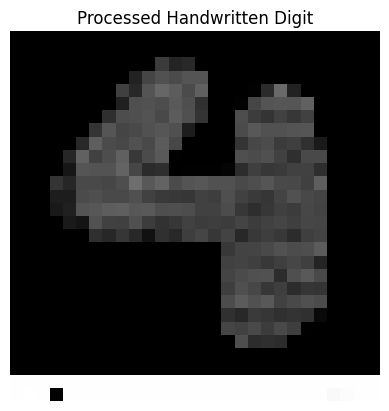

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted Digit: 9


In [15]:
# Open In Colab

from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Step 1: Upload External Handwritten Image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Step 2: Load or Train MNIST Model
try:
    # Try loading a saved model
    model = load_model("mnist_model.h5")
    print("Loaded pre-trained MNIST model.")
except:
    print("No saved model found. Training a new one...")
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    # Reshape and normalize
    x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)

    # Build CNN model
    model = Sequential([
        Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    model.fit(x_train, y_train, epochs=6, batch_size=128, validation_data=(x_test, y_test))

    # Save model for reuse
    model.save("mnist_model.h5")

# Step 3: Preprocess Uploaded Image
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = 255 - gray   # invert colors (white background, black digit)
resized = cv2.resize(gray, (28, 28))
plt.imshow(resized, cmap="gray")
plt.title("Processed Handwritten Digit")
plt.axis("off")
plt.show()

# Normalize and reshape
resized = resized / 255.0
input_image = resized.reshape(1, 28, 28, 1)

# Step 4: Predict Digit
prediction = model.predict(input_image)
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)